#**[Wildfire Prediction using Time Series Analysis](https://www.sciencebuddies.org/)**

This notebook was developed by Science Buddies [www.sciencebuddies.org](https://www.sciencebuddies.org/) as part of a science project to allow students to explore and learn about artificial intelligence. For personal use, this notebook can be downloaded and modified with attribution. For all other uses, please see our [Terms and Conditions of Fair Use](https://www.sciencebuddies.org/about/terms-and-conditions-of-fair-use).  

**Troubleshooting tips**
*   Read the written instructions at Science Buddies and the text and comments on this page carefully.
*   If you make changes that break the code, you can download a fresh copy of this notebook and start over.

*   If you are using this notebook for a science project and need help, visit our [Ask an Expert](https://www.sciencebuddies.org/science-fair-projects/ask-an-expert-intro) forum for assistance.

## **How To Use This Notebook**

This notebook contains text fields, like this one, that give you information about the project and instructions.

# Importing Libraries

In [47]:
# --- Core libraries ---
import warnings                       # To handle warning messages
import glob                           # For working with file paths/patterns

# --- Data manipulation ---
import pandas as pd                   # Data analysis and manipulation
import numpy as np                    # Numerical computations

# --- Visualization ---
import matplotlib.pyplot as plt       # Plotting
import matplotlib.colors as mcolors   # Advanced color handling for matplotlib
import seaborn as sns                 # Statistical plotting (built on matplotlib)
import folium                         # Interactive maps
import branca.colormap as cm          # Colormaps for Folium visualizations

# --- Machine learning / forecasting ---
from prophet import Prophet           # Time series forecasting
from sklearn.metrics import mean_absolute_error  # Model evaluation metric

# --- Pandas extensions ---
from pandas.api.types import CategoricalDtype    # Handling categorical dtypes

# --- Global settings ---
warnings.filterwarnings("ignore")     # Suppress warnings
plt.style.use('ggplot')               # Set plot style
plt.style.use('fivethirtyeight')      # Override with another style

# --- Custom utility functions ---
def mean_absolute_percentage_error(y_true, y_pred):
    """Calculates Mean Absolute Percentage Error (MAPE) given y_true and y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Loading the Data into a Pandas DataFrame

Code Block 1A

In [48]:
import os
import pandas as pd

folder_path = os.path.join('data', 'historicos_españa', 'años')
output_path = os.path.join('data', 'historicos_españa', 'modis_historicos_españa.csv')

csv_files = [os.path.join(folder_path, f) for f in os.listdir(folder_path) if f.endswith('.csv')]

df_españa = pd.concat((pd.read_csv(file) for file in csv_files), ignore_index=True)

df_españa.to_csv(output_path, index=False)
df_españa.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,43.5326,-5.7263,316.4,1.0,1.0,2017-01-01,235,Aqua,MODIS,93,6.2,275.1,20.6,N,0
1,42.3891,-6.5918,300.4,1.0,1.0,2017-01-01,236,Aqua,MODIS,27,6.2,269.8,9.6,N,0
2,43.0390,-6.5395,317.5,1.0,1.0,2017-01-01,236,Aqua,MODIS,95,6.2,272.6,21.5,N,0
3,42.8756,-5.0808,301.0,1.3,1.1,2017-01-01,1342,Aqua,MODIS,43,6.2,280.8,10.7,D,0
4,42.3787,-6.5832,308.9,1.1,1.1,2017-01-01,1342,Aqua,MODIS,43,6.2,283.5,11.4,D,0


Code Block 1B

# Visualizing the Data

Code Block 2A

In [49]:
def plot_frp_by_timeframe(df, year, month=None, date_col='acq_date'):
    """
    Generates a line plot or bar graph of FRP. 
    Saves you from manually setting the datetime index.
    """
    df_filtered = df.copy()
    
    # Si la fecha es una columna, la convertimos y la pasamos temporalmente al índice
    if date_col in df_filtered.columns:
        df_filtered[date_col] = pd.to_datetime(df_filtered[date_col])
        df_filtered = df_filtered.set_index(date_col)
        
    if month is not None:
        df_filtered = df_filtered[(df_filtered.index.year == year) & (df_filtered.index.month == month)]
        timeframe_str = f"Fire Radiative Power (FRP) for {month}/{year}"
        plot_type = 'line'
    else:
        df_filtered = df_filtered[df_filtered.index.year == year]
        timeframe_str = f"Monthly Median Fire Radiative Power (FRP) for {year}"
        plot_type = 'bar'

    if df_filtered.empty:
        print(f"No data found for {timeframe_str.replace('Monthly Median ', '')}")
        return

    plt.figure(figsize=(12, 6))

    if plot_type == 'line':
        plt.plot(df_filtered.index, df_filtered['frp'])
        plt.xlabel('Date')
        plt.ylabel('FRP')
    elif plot_type == 'bar':
        # En versiones recientes de pandas se recomienda usar 'ME' en lugar de 'M'
        monthly_frp = df_filtered.resample('ME')['frp'].median()
        monthly_frp.index = monthly_frp.index.strftime('%Y-%m') 
        monthly_frp.plot(kind='bar')
        plt.xlabel('Month')
        plt.ylabel('Median FRP')
        plt.xticks(rotation=45, ha='right') 

    plt.title(timeframe_str)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Code Block 2B

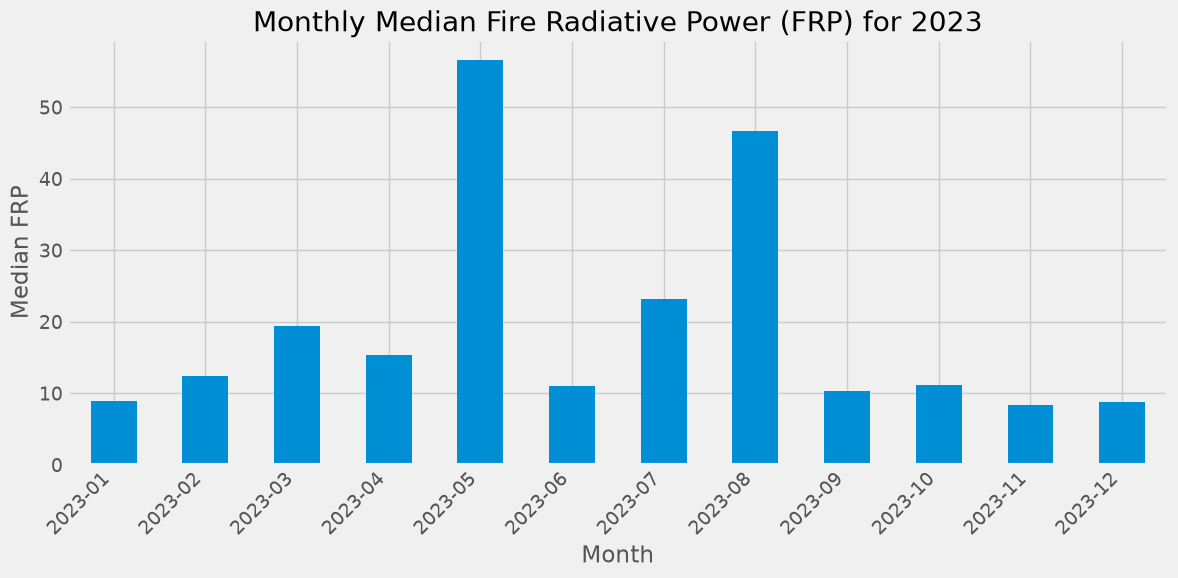

In [50]:
# TODO: Change year
year = 2023

 # Bar graph for the year
plot_frp_by_timeframe(df_españa, year)

Code Block 2C

In [51]:
import folium
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import branca.colormap as cm

def plot_intense_fires_folium(df_españa, year, month=None):
    if month is not None:
        df_filtered = df_españa[(df_españa.index.year == year) & (df_españa.index.month == month)].copy()
        timeframe_str = f"Intense Fires for {month}/{year}"
    else:
        df_filtered = df_españa[df_españa.index.year == year].copy()
        timeframe_str = f"Intense Fires for {year}"

    intense_fires_df = df_filtered[df_filtered['frp'] >= 100].copy()

    if intense_fires_df.empty:
        print(f"No intense fires found for {timeframe_str}")
        return

    m = folium.Map(location=[40.416775, -3.703790], zoom_start=6)

    max_frp = intense_fires_df['frp'].max()
    min_frp = intense_fires_df['frp'].min()

    cmap = plt.colormaps.get_cmap('YlOrRd')
    norm = mcolors.Normalize(vmin=min_frp, vmax=max_frp)

    for index, row in intense_fires_df.iterrows():
        radius = 2 + (row['frp'] - min_frp) / (max_frp - min_frp) * 13 if max_frp > min_frp else 5
        opacity = 0.4 + (row['frp'] - min_frp) / (max_frp - min_frp) * 0.5 if max_frp > min_frp else 0.7
        color = mcolors.to_hex(cmap(norm(row['frp'])))

        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=opacity,
            tooltip=f"FRP: {row['frp']:.2f}"
        ).add_to(m)

    colormap = cm.LinearColormap(
        colors=['yellow', 'orange', 'red'],
        index=[0, 250, 500],
        vmin=0,
        vmax=500
    )

    colormap.caption = 'Fire Radiative Power (FRP)'
    colormap.add_to(m)

    display(m)

In [52]:
if 'acq_date' in df_españa.columns:
    df_españa['acq_date'] = pd.to_datetime(df_españa['acq_date'])
    df_españa = df_españa.set_index('acq_date')
elif df_españa.index.name == 'acq_date':
    pass
else:
    print("Columnas disponibles:", df_españa.columns)
    print("Nombre del índice actual:", df_españa.index.name)

year = 2022
month = 7

plot_intense_fires_folium(df_españa, year, month)

# Preprocessing

Code Block 3A

In [53]:
# List of column names that we don't need for our analysis
columns_to_drop = ['acq_time', 'satellite', 'instrument', 'version', 'daynight']

# Remove the specified columns from the DataFrame "df"
# inplace=True means the change is applied directly to df without creating a new DataFrame
df_españa.drop(columns=columns_to_drop, inplace=True)

# Display the first 5 rows of the updated DataFrame to confirm the columns were removed
df_españa.head()

,latitude,longitude,brightness,scan,track,confidence,bright_t31,frp,type
acq_date,,,,,,,,,
2017-01-01,43.5326,-5.7263,316.4,1.0,1.0,93,275.1,20.6,0
2017-01-01,42.3891,-6.5918,300.4,1.0,1.0,27,269.8,9.6,0
2017-01-01,43.0390,-6.5395,317.5,1.0,1.0,95,272.6,21.5,0
2017-01-01,42.8756,-5.0808,301.0,1.3,1.1,43,280.8,10.7,0
2017-01-01,42.3787,-6.5832,308.9,1.1,1.1,43,283.5,11.4,0


Code Block 3B

In [54]:
# TODO: Adjust latitude and longitude to the region you want
min_latitude, max_latitude = 32, 42
min_longitude, max_longitude = -124, -114

# Filter by latitude and longitude bounds
df_españa_filtered = df_españa[(df_españa['latitude'] >= min_latitude) & (df_españa['latitude'] <= max_latitude) & (df_españa['longitude'] >= min_longitude) & (df_españa['longitude'] <= max_longitude)]

print(f"Number of rows after filtering: {len(df_españa_filtered)}")

Number of rows after filtering: 0


Code Block 3C

In [55]:
# Create a map centered around the area
m = folium.Map(location=[(min_latitude + max_latitude) / 2, (min_longitude + max_longitude) / 2], zoom_start=6)

# Add a rectangle representing the boundaries
folium.Rectangle(
    bounds=[(min_latitude, min_longitude), (max_latitude, max_longitude)],
    color='#ff7800',
    weight=2,
    fill=True,
    fill_color='#ffff00',
    fill_opacity=0.2
).add_to(m)

# Display the map
display(m)

Code Block 3D

In [56]:
# Aggregate by daily, drop latitude and longitude, and median other features
df_españa = df_españa_filtered.resample('D').median()

# Drop NaN values
df_españa.dropna(inplace=True)

# Display the dataset
df_españa.head()

,latitude,longitude,brightness,scan,track,confidence,bright_t31,frp,type
acq_date,,,,,,,,,


# Visualizing Region Data

Code Block 4A

ValueError: zero-size array to reduction operation fmin which has no identity

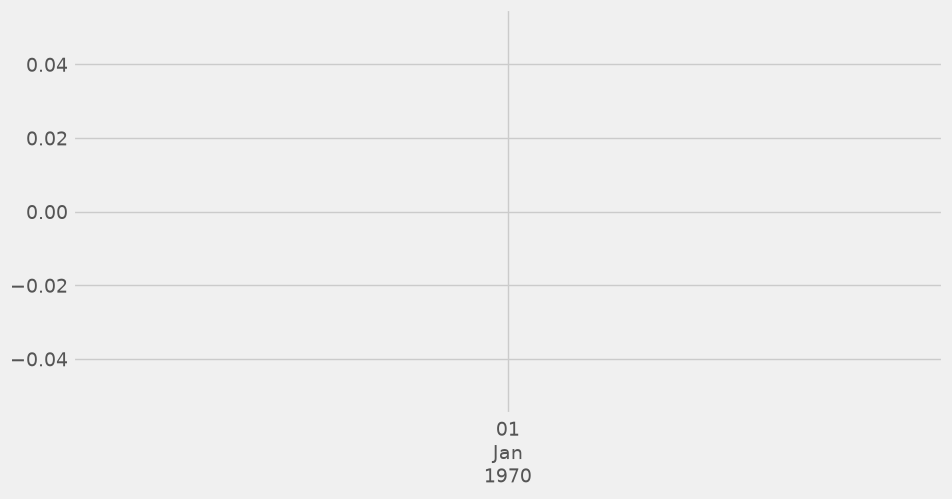

In [61]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

if 'acq_date' in df_españa.columns:
    df_españa['acq_date'] = pd.to_datetime(df_españa['acq_date'])
    df_españa = df_españa.set_index('acq_date')

df_españa = df_españa.dropna(subset=['frp'])

color_pal = sns.color_palette()

df_españa.plot(
    style='.',
    y='frp',
    figsize=(10, 5),
    ms=1,
    color=color_pal[0],
    title='Wildfire Data',
    alpha=0.5
)

plt.xlabel('Date')
plt.ylabel('FRP')

Code Block 4B

In [ ]:
def create_features(df):
    """
    Creates time series features from datetime index and concatenates to original df.
    """
    df = df.copy()
    df['date'] = df.index
    df['month'] = df['date'].dt.month
    df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
    df['date_offset'] = (df.date.dt.month*100 + df.date.dt.day - 320)%1300

    df['season'] = pd.cut(df['date_offset'], [0, 300, 602, 900, 1300],
                          labels=['Spring', 'Summer', 'Fall', 'Winter']
                   )
    df = df.drop(columns=['date', 'date_offset']) # Drop temporary columns

    return df

df_features = create_features(df)
X = df_features.drop(columns=['frp'])
y = df_features['frp']

Code Block 4C

In [ ]:
fig, ax = plt.subplots(figsize=(15, 10)) # Increased figure size
sns.boxplot(data=df_features.dropna(),
            x='season',
            y='frp',
            hue='season',
            ax=ax,
            linewidth=0.5) # Slightly reduced linewidth
ax.set_title('FRP by Day of Year and Season')
ax.set_xlabel('Season')
ax.set_ylabel('FRP')
ax.legend(bbox_to_anchor=(1, 1))
plt.show()

# Splitting Data into Train and Test

Code Block 5A

In [ ]:
# TODO: Change date
split_date = '1-Jan-2024'
df_train = df_features.loc[df_features.index <= split_date].copy()
df_test = df_features.loc[df_features.index > split_date].copy()

# Plot train and test so you can see where we have split
pd.concat([df_test.groupby(df_test.index)['frp'].mean().rename('TEST SET'),
           df_train.groupby(df_train.index)['frp'].mean().rename('TRAINING SET')],
          axis=1) \
    .plot(figsize=(10, 5), title='Wildfire FRP', style='.', ms=1)
plt.show()

# Training the Model

Code Block 6A

In [ ]:
# Format data for prophet model using ds and y
df_train_prophet = df_train.reset_index() \
    .rename(columns={'acq_date':'ds',
                     'frp':'y'})

Code Block 6B

In [ ]:
%%time
# Initialize and train the Prophet model
# The Prophet model is a time series forecasting model developed by Facebook
model = Prophet()
# Fit the model to the training data
# This step can take some time as the model learns the patterns in the data
model.fit(df_train_prophet)

# Evaluating the Model

Code Block 7A

In [ ]:
# Predict on test set with model
df_test_prophet = df_test.reset_index() \
    .rename(columns={'acq_date':'ds',
                     'frp':'y'})

# Use the trained Prophet model to make predictions on the test data
df_test_fcst = model.predict(df_test_prophet)

Code Block 7B

In [ ]:
# Create a figure and axis for plotting, setting the figure size
fig, ax = plt.subplots(figsize=(10, 5))

# Plot the Prophet forecast results on the specified axis
fig = model.plot(df_test_fcst, ax=ax)

# Plot the actual values from the test set as scatter points
ax.scatter(df_test_prophet['ds'], df_test_prophet['y'], color='black', s=5)

# Set the plot title
ax.set_title('Prophet Forecast vs Actual')
yaxis = ax.get_yaxis()
yaxis.set_label_text('FRP')

# Add a legend to differentiate between forecast and actual values
ax.legend()

# Display the plot
plt.show()

Code Block 7C

In [ ]:
# Make a graph to compare prediction to actual values with rolling median for the test set
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_test_fcst['ds'], df_test_fcst['yhat'], label='Prophet Forecast', alpha=0.7)
ax.plot(df_test_prophet['ds'], df_test_prophet['y'], label='Actual', alpha=0.7)

# TODO: You can adjust the window size
rolling_window = 28

# Calculate and plot rolling median
df_test_prophet['rolling_avg'] = df_test_prophet['y'].rolling(window=rolling_window).median()
ax.plot(df_test_prophet['ds'], df_test_prophet['rolling_avg'], label=f'Rolling Median ({rolling_window} days)', alpha=0.7)

ax.set_title('Prophet Forecast vs Actual with Rolling Median (2024)')
ax.set_xlabel('Date')
ax.set_ylabel('FRP')
ax.legend()
plt.show()

Code Block 7D

In [ ]:
# Calculate MAE
mae = mean_absolute_error(df_test['frp'], df_test_fcst['yhat'])
print('MAE:', mae)

Code Block 7E

In [ ]:
# Calculate MAPE
mean_absolute_percentage_error(df_test['frp'], df_test_fcst['yhat'])

Code Block 7F

In [ ]:
def plot_prophet_predictions_folium(df_fcst, year, month=None):
    """
    Generates an interactive map showing the locations of Prophet model predictions
    for a specific year and optional month using Folium, with color scaling by predicted FRP.

    Args:
        df_fcst (pd.DataFrame): The input DataFrame with 'ds', 'yhat', 'latitude',
                                'longitude' columns (from Prophet forecast and original data).
        year (int): The year to filter by.
        month (int, optional): The month to filter by (1-12). Defaults to None.
    """
    # Ensure 'ds' is datetime and set as index for filtering
    df_fcst['ds'] = pd.to_datetime(df_fcst['ds'])
    df_fcst.set_index('ds', inplace=True)

    if month is not None:
        df_filtered = df_fcst[(df_fcst.index.year == year) & (df_fcst.index.month == month)].copy()
        timeframe_str = f"Prophet Predictions for {month}/{year}"
    else:
        df_filtered = df_fcst[df_fcst.index.year == year].copy()
        timeframe_str = f"Prophet Predictions for {year}"

    # Drop rows with NaN in latitude or longitude
    df_filtered.dropna(subset=['latitude', 'longitude'], inplace=True)

    if df_filtered.empty:
        print(f"No predictions with location data found for {timeframe_str}")
        return

    # Create a base map of the US
    m = folium.Map(location=[37.0902, -95.7129], zoom_start=4)

    # Add markers for predicted fire locations
    # Use 'yhat' for coloring and radius
    max_yhat = df_filtered['yhat'].max()
    min_yhat = df_filtered['yhat'].min()

    # Create a colormap for yhat values
    cmap = plt.cm.get_cmap('YlOrRd') # Yellow to Red colormap
    norm = mcolors.Normalize(vmin=min_yhat, vmax=max_yhat)

    for index, row in df_filtered.iterrows():
        # Scale yhat to a reasonable range for radius (e.g., 2 to 15)
        radius = 2 + (row['yhat'] - min_yhat) / (max_yhat - min_yhat) * 13 if max_yhat > min_yhat else 5
        # Scale yhat to a reasonable range for opacity (e.g., 0.4 to 0.9)
        opacity = 0.4 + (row['yhat'] - min_yhat) / (max_yhat - min_yhat) * 0.5 if max_yhat > min_yhat else 0.7

        # Get color from colormap based on yhat value
        color = mcolors.to_hex(cmap(norm(row['yhat'])))

        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=radius,
            color=color,
            fill=True,
            fill_color=color,
            fill_opacity=opacity,
            tooltip=f"Predicted FRP: {row['yhat']:.2f}"
        ).add_to(m)


      # Add a legend
    colormap = cm.LinearColormap(
        colors=['yellow', 'orange', 'red'],
        index=[0, 250, 500],   # evenly spaced points in the range
        vmin=0,
        vmax=500
    )

    # Add the colormap as a legend to the map
    colormap.caption = 'Fire Radiative Power (FRP)'
    colormap.add_to(m)

    # Display the map
    display(m)

Code Block 7G

In [ ]:
# TODO: Change year and month
year = 2024
month = 7

# Merge latitude and longitude from df_test_prophet into df_test_fcst
df_test_fcst_merged = df_test_fcst.merge(df_test_prophet[['ds', 'latitude', 'longitude']], on='ds', how='left')

plot_prophet_predictions_folium(df_test_fcst_merged, year, month)

Code Block 7H

In [ ]:
# TODO: Change year and month
year = 2024
month = 7

# Plot actual fires
plot_intense_fires_folium(df, year)